``` Họ và tên: Phạm Ngọc Hào```

``` MSSV: 23110146```

# 1. Thực thi code ở phòng lab

- Import thư viện và chuẩn bị dữ liệu

In [1]:
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from numpy import random
from pandas import DataFrame
from sklearn.cluster import KMeans
import seaborn as sns

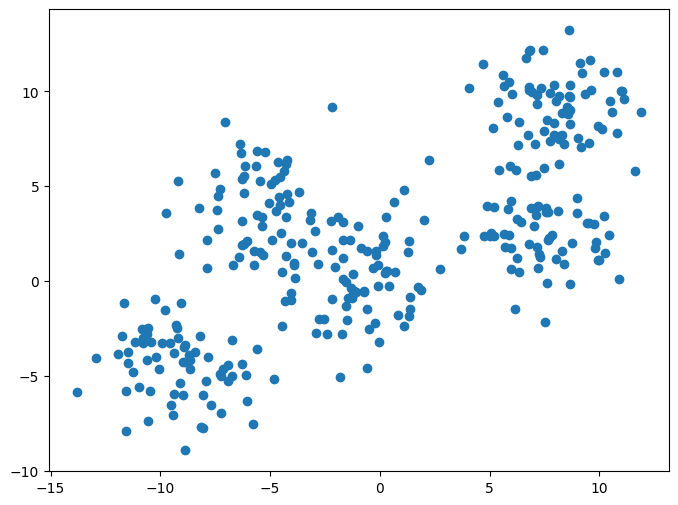

In [2]:
random.seed(234)
x,y=make_blobs(n_samples=330, centers=5,cluster_std=1.84)
plt.figure(figsize=(8,6))
plt.scatter(x[:,0],x[:,1])
plt.show()

- Mô hình

In [3]:
gm= GaussianMixture(n_components=5).fit(x)
centers=gm.means_
print(centers)

[[-5.55836831  3.87299888]
 [ 7.28418475  2.56387124]
 [-0.90246061  0.16230294]
 [-9.18288987 -4.47852917]
 [ 8.11454324  9.24741885]]


- Vẽ các tâm của mỗi vùng dữ liệu

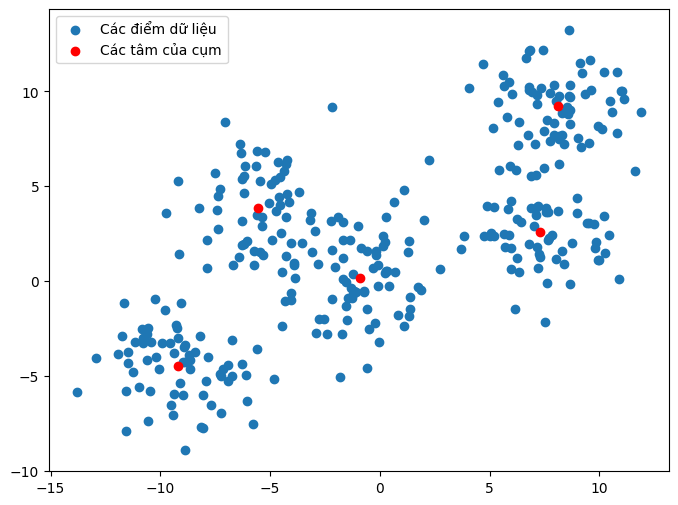

In [4]:
plt.figure(figsize=(8,6))
plt.scatter(x[:,0],x[:,1],label="Các điểm dữ liệu")
plt.scatter(centers[:,0],centers[:,1],c='r',label="Các tâm của cụm")
plt.legend()
plt.show()

- Dự đoán và trực quan hóa

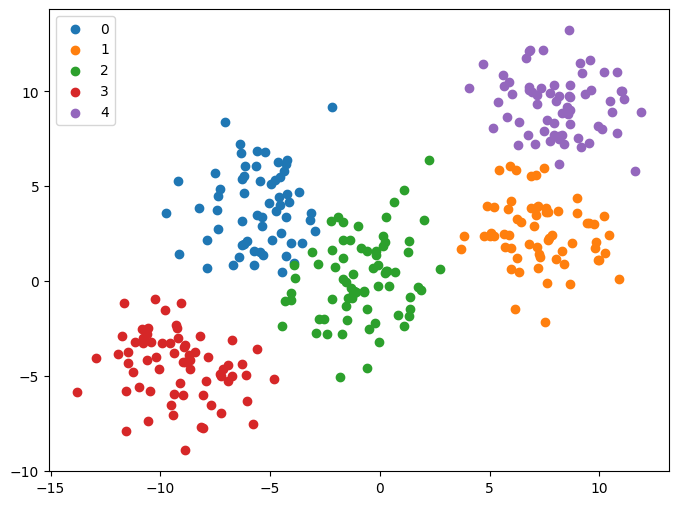

In [5]:
pred=gm.predict(x)
df=DataFrame({'x':x[:,0],'y':x[:,1],'label':pred})
groups=df.groupby('label')

fig,ax=plt.subplots(figsize=(8,6))
for name, group in groups:
    ax.scatter(group.x,group.y,label=name)

ax.legend()
plt.show()

- Thay đổi số cụm và vẽ trên đồ thị

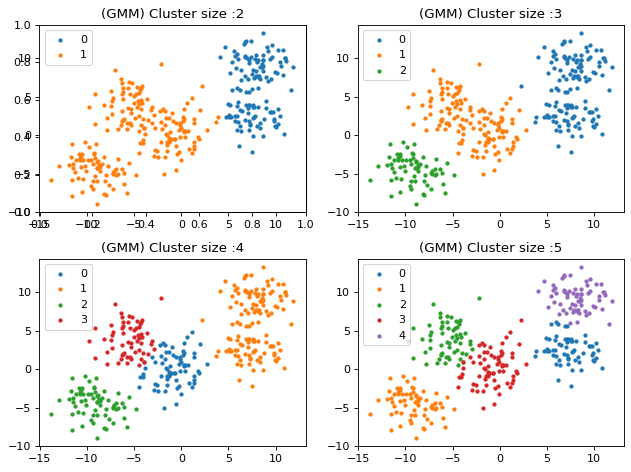

In [6]:
fig = plt.figure(figsize=(8,6),dpi=80)
fig.add_subplot(2,2,1)

for i in range(2,6):
    gm=GaussianMixture(n_components=i).fit(x)
    pred=gm.predict(x)
    df=DataFrame({'x':x[:,0],'y':x[:,1],'label':pred})
    groups=df.groupby('label')
    fig.add_subplot(2,2,i-1)
    for name,group in groups:
        plt.scatter(group.x,group.y,label=name,s=8)
        plt.title("(GMM) Cluster size :" + str(i))
        plt.legend()

plt.tight_layout()
plt.show()

- Sử dụng Kmeans

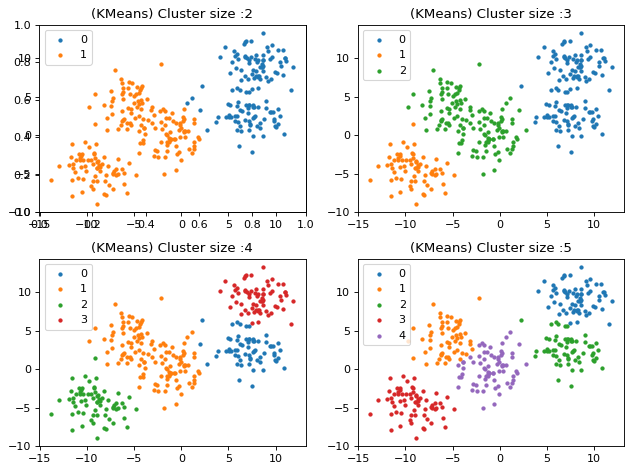

In [7]:
fig = plt.figure(figsize=(8,6),dpi=80)
fig.add_subplot(2,2,1)

for i in range(2,6):
    km=KMeans(n_clusters=i).fit(x)
    pred=km.predict(x)
    df=DataFrame({'x':x[:,0],'y':x[:,1],'label':pred})
    groups=df.groupby('label')
    fig.add_subplot(2,2,i-1)
    for name,group in groups:
        plt.scatter(group.x,group.y,label=name,s=8)
        plt.title("(KMeans) Cluster size :" + str(i))
        plt.legend()

plt.tight_layout()
plt.show()

# 2. Xây dựng thuật toán Manhatlanobis K-means

- Mô hình

In [9]:
import numpy as np
from scipy.spatial.distance import cdist

class MahalanobisKMeans:
    def __init__(self, n_clusters=5, max_iter=100, random_state=None):
        """
        Khởi tạo mô hình Mahalanobis K-Means.
        """
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state
        
        self.cluster_centers_ = None
        self.covariances_ = None
        self.labels_ = None
        self.n_iter_ = 0

    def fit(self, X):
        """
        Huấn luyện mô hình với dữ liệu X.
        """
        if self.random_state is not None:
            np.random.seed(self.random_state)
            
        initial_idx = np.random.choice(X.shape[0], self.n_clusters, replace=False)
        self.cluster_centers_ = X[initial_idx].copy().astype(float)
        
        euclidean_distances = cdist(X, self.cluster_centers_, 'euclidean')
        labels = np.argmin(euclidean_distances, axis=1)
        
        self.covariances_ = []
        for k in range(self.n_clusters):
            cluster_points = X[labels == k]
            if len(cluster_points) > 1:
                self.covariances_.append(np.cov(cluster_points, rowvar=False))
            else:
                self.covariances_.append(np.eye(X.shape[1]))
                
        for iteration in range(self.max_iter):
            old_labels = labels.copy()
            
            labels = self._assign_labels(X)
            
            for k in range(self.n_clusters):
                cluster_points = X[labels == k]
                if len(cluster_points) > 0:
                    self.cluster_centers_[k] = np.mean(cluster_points, axis=0)
                    if len(cluster_points) > 1:
                        self.covariances_[k] = np.cov(cluster_points, rowvar=False)
                    else:
                        self.covariances_[k] = np.eye(X.shape[1])
                        
            if np.all(old_labels == labels):
                self.n_iter_ = iteration + 1
                break
                
        self.labels_ = labels
        return self

    def _assign_labels(self, X):
        """
        Hàm dùng chung để tính khoảng cách Mahalanobis và trả về nhãn cụm.
        """
        distances = np.zeros((X.shape[0], self.n_clusters))
        for k in range(self.n_clusters):
            try:
                inv_cov = np.linalg.inv(self.covariances_[k])
            except np.linalg.LinAlgError:
                inv_cov = np.eye(X.shape[1])
            
            diff = X - self.cluster_centers_[k]
            distances[:, k] = np.sum(np.dot(diff, inv_cov) * diff, axis=1)
            
        return np.argmin(distances, axis=1)

    def predict(self, X):
        """
        Dự đoán nhãn cụm cho dữ liệu mới.
        """
        if self.cluster_centers_ is None:
            raise ValueError("Mô hình chưa được huấn luyện. Hãy gọi hàm fit() trước.")
        return self._assign_labels(X)
        
    def fit_predict(self, X):
        """
        Huấn luyện và trả về nhãn cụm của dữ liệu huấn luyện.
        """
        self.fit(X)
        return self.labels_

- Dự đoán và trực quan hóa kết quả

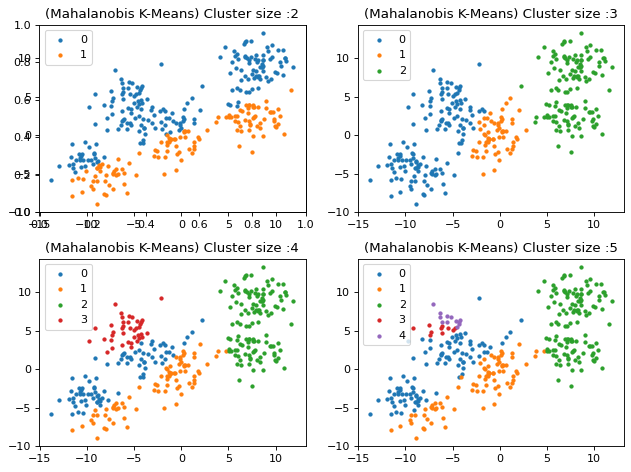

In [14]:
fig = plt.figure(figsize=(8,6),dpi=80)
fig.add_subplot(2,2,1)

for i in range(2,6):
    man_kmeans = MahalanobisKMeans(n_clusters=i, max_iter=100, random_state=234)
    pred = man_kmeans.fit_predict(x)
    df = DataFrame({'x': x[:, 0], 'y': x[:, 1], 'label': pred})
    groups = df.groupby('label')
    fig.add_subplot(2,2,i-1)
    for name,group in groups:
        plt.scatter(group.x,group.y,label=name,s=8)
        plt.title("(Mahalanobis K-Means) Cluster size :" + str(i))
        plt.legend()

plt.tight_layout()
plt.show()